# 第11章 二值选择模型

## 11.1 二值选择模型的例子

有时被解释变量y是离散的，而非连续的，称为离散选择模型(discrete choice model)或定性反应模型(qualitative response model)。最常见的离散选择模型是二值选择行为(binary choices)。

Probit模型：
$$
P(y=1|x)=F(x,\beta)=\Phi(x^\prime\beta)=\int_{-\infty}^{x^\prime\beta}\phi(t)dt
$$
- 其中，$\phi(\cdot)$和$\Phi(\cdot)$分别为标准正态的密度函数与累积分布函数。

Logit模型：
$$
P(y=1|x)=F(x,\beta)=\Lambda(x^\prime\beta)=\frac{\exp(x^\prime\beta)}{1+\exp(x^\prime\beta)}
$$

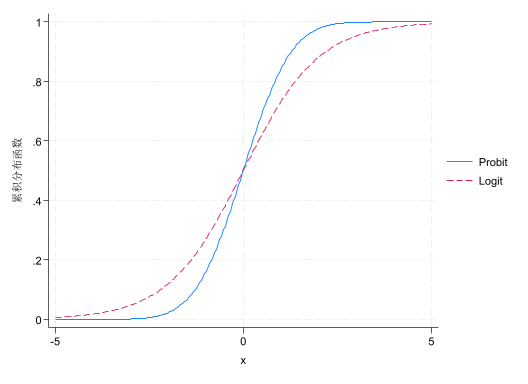

In [1]:
* 标准正态分布与逻辑分布的累积分布函数
twoway function Probit=normal(x),range(-5 5) || function Logit=exp(x)/(1+exp(x)),range(-5 5) lp(dash) ytitle("累积分布函数")

### 11.4 三种边际效应

对于线性模型，回归系数$\beta_k$的经济意义十分明显，就是解释变量$x_k$对被解释变量y的边际效应(marginal effects)。

在非线性模型中，估计量$\hat\beta_{ML}$一般并非边际效应。以Probit为例，计算解释变量$x_k$的边际效应：
$$
\frac{\partial P(y=1|x)}{\partial x_k}=\frac{\partial\Phi(x^\prime\beta)}{\partial x_k}=\frac{\partial\Phi(x^\prime\beta)}{\partial(x^\prime\beta)}\cdot\frac{\partial(x^\prime\beta)}{\partial x^\prime\beta}=\phi(x^\prime\beta)\cdot\beta_k
$$

由于非线性模型的边际效应一般不是常数，故存在不同的边际效应概念。常用的边际效应概念包括：
1. 平均边际效应(average marginal effect)，即分别计算在每个样本观测值上的边际效应，然后进行简单算术平均。
2. 样本均值处的边际效应(marginal effect at mean)，即计算在x=z处的边际效应。
3. 某代表值处的边际效应(marginal effect at a representative value)，即给定$x^*$，计算在$x=x^*$处的边际效应。

## 11.9 二值选择模型的Stata命令及实例

二值选择模型的Stata命令为：
```
probit y x1 x2 x3,r   (Probit模型)
logit y x1 x2 x3,r or (Logit模型)
```
- 选择项“r”表示使用稳健标准误(默认为普通标准误)
- 选择项“or”表示显示几率比(odds ratio)，而不显示回归系数

完成Probit或Logit估计后，可进行预测，计算准确预测的百分比，或计算边际效应：
```
* 计算发生概率的预测值，记为y1
predict y1
* 计算准确预测的百分比，clas表示classification
estat clas
* 计算所有解释变量的平均边际效应；“*”代表所有解释变量
margins,dydx(*)
* 计算所有解释变量在样本均值处的边际效应
margins,dydx(*) atmeans
* 计算所有解释变量在x1=0处的平均边际效应
margins,dydx(*) at(x1=0)
* 计算解释变量x1的平均边际效应
margins,dydx(x1)
* 计算平均弹性，其中的两个“e”均指elasticity
margins,eyex(*)
* 计算平均半弹性，x变化一单位引起y变化百分之几
margins,eydx(*)
* 计算平均半弹性，x变化1%起y变化几个单位
margins,dyex(*)
```

titanic.dta数据集的被解释变量为survive(存活=1,死亡=0)；解释变量包括：
- child(儿童=1,成年=0)
- female(女性=1,男性=0)
- class1(头等舱=1,其他=0)
- class2(二等舱=1,其他=0)
- class3(三等舱=1,其他=0)
- class4(船员=1,其他=0)

In [2]:
use data/titanic.dta,clear
list


     +---------------------------------------------------------------------+
     | class1   class2   class3   class4   child   female   survive   freq |
     |---------------------------------------------------------------------|
  1. |      0        0        1        0       1        0         0     35 |
  2. |      0        0        1        0       1        1         0     17 |
  3. |      1        0        0        0       0        0         0    118 |
  4. |      0        1        0        0       0        0         0    154 |
  5. |      0        0        1        0       0        0         0    387 |
     |---------------------------------------------------------------------|
  6. |      0        0        0        1       0        0         0    670 |
  7. |      1        0        0        0       0        1         0      4 |
  8. |      0        1        0        0       0        1         0     13 |
  9. |      0        0        1        0       0        1         0     89 

In [3]:
* 假设观测值的重复次数记录于变量freg，则在Stata中，可通过在命令的最后加上“[fweight=freq]”来实现此加权计算或估计；其中“fweight”指“frequencyweight”(频数权重)
sum [fweight=freq]


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
      class1 |      2,201    .1476602    .3548434          0          1
      class2 |      2,201    .1294866     .335814          0          1
      class3 |      2,201    .3207633     .466876          0          1
      class4 |      2,201      .40209    .4904313          0          1
       child |      2,201    .0495229    .2170065          0          1
-------------+---------------------------------------------------------
      female |      2,201    .2135393    .4098983          0          1
     survive |      2,201     .323035    .4677422          0          1
        freq |      2,201    329.2726    250.0362          1        670


从上表可知，样本容量为2201(旅客与船员总人数)，而非24。从变量survive的平均值可知，泰坦尼克号的平均存活率为0.32。

In [4]:
* 下面分别计算小孩、女士以及各等舱旅客的存活率。
sum survive if child [fweight=freq]


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     survive |        109    .5229358    .5017807          0          1


In [5]:
sum survive if female [fweight=freq]


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     survive |        470    .7319149    .4434342          0          1


In [6]:
sum survive if class1 [fweight=freq]


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     survive |        325    .6246154    .4849687          0          1


In [7]:
sum survive if class2 [fweight=freq]


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     survive |        285    .4140351     .493421          0          1


In [8]:
sum survive if class3 [fweight=freq]


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     survive |        706    .2521246    .4345403          0          1


In [9]:
sum survive if class4 [fweight=freq]


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     survive |        885     .239548     .427049          0          1


从以上结果可知，小孩、女士、一等舱、二等舱的存活率分别为0.52、0.73、0.62、0.41，高于平均存活率；而三等舱、船员的存活率分别为0.25、0.24，低于平均存活率。

In [10]:
* 首先使用OLS估计线性概率模型
reg survive child female class1 class2 class3 [fweight=freq],r


Linear regression                               Number of obs     =      2,201
                                                F(5, 2195)        =     221.66
                                                Prob > F          =     0.0000
                                                R-squared         =     0.2529
                                                Root MSE          =     .40474

------------------------------------------------------------------------------
             |               Robust
     survive | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       child |   .1812957   .0479499     3.78   0.000     .0872639    .2753275
      female |   .4906798   .0239292    20.51   0.000     .4437535    .5376061
      class1 |   .1755538   .0291386     6.02   0.000     .1184117     .232696
      class2 |  -.0105263   .0258402    -0.41   0.684       -.0612    .0401475
      class3 |

上表显示，儿童(child)、妇女(female)与头等舱旅客(class1)的存活概率均显著地更高，三等舱旅客(class3)的存活概率显著地更低，而二等舱旅客(class2)的存活概率与船员无显著差异。

In [11]:
* 其次，使用Logit进行估计：
* 选择项“nolog”表示不显示MLE数值计算的迭代过程
logit survive child female class1 class2 class3 [fweight=freq],nolog


Logistic regression                                     Number of obs =  2,201
                                                        LR chi2(5)    = 559.40
                                                        Prob > chi2   = 0.0000
Log likelihood = -1105.0306                             Pseudo R2     = 0.2020

------------------------------------------------------------------------------
     survive | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
       child |   1.061542   .2440257     4.35   0.000     .5832608    1.539824
      female |    2.42006   .1404101    17.24   0.000     2.144862    2.695259
      class1 |   .8576762   .1573389     5.45   0.000     .5492976    1.166055
      class2 |  -.1604188   .1737865    -0.92   0.356    -.5010342    .1801966
      class3 |  -.9200861   .1485865    -6.19   0.000     -1.21131   -.6288619
       _cons |  -1.233899   .0804946   -15.33   0.

Logit模型的估计结果在变量的显著性方面与OLS完全一致。上表显示，准$R^2$为0.20。检验整个方程显著性的LR统计量(LR chi2(5))为559.40，对应的p值为0.000，故整个方程的联合显著性很高。

In [12]:
* 下面使用稳健标准误进行Logit估计
logit survive child female class1 class2 class3 [fweight=freq],nolog r


Logistic regression                                     Number of obs =  2,201
                                                        Wald chi2(5)  = 467.05
                                                        Prob > chi2   = 0.0000
Log pseudolikelihood = -1105.0306                       Pseudo R2     = 0.2020

------------------------------------------------------------------------------
             |               Robust
     survive | Coefficient  std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
       child |   1.061542   .2767452     3.84   0.000     .5191318    1.603953
      female |    2.42006   .1363096    17.75   0.000     2.152898    2.687222
      class1 |   .8576762   .1475218     5.81   0.000     .5685387    1.146814
      class2 |  -.1604188   .1502193    -1.07   0.286    -.4548432    .1340056
      class3 |  -.9200861   .1621035    -5.68   0.000    -1.237803    -.602369
       _cons |

对比以上两表可知，稳健标准误与普通标准误比较接近。

由于此回归中的解释变量均为虚拟变量，只能变化一个单位(从0变为1)，为了便于解释回归结果，下面让Stata汇报几率比而非系数。

In [13]:
logit survive child female class1 class2 class3 [fweight=freq],or nolog


Logistic regression                                     Number of obs =  2,201
                                                        LR chi2(5)    = 559.40
                                                        Prob > chi2   = 0.0000
Log likelihood = -1105.0306                             Pseudo R2     = 0.2020

------------------------------------------------------------------------------
     survive | Odds ratio   Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
       child |   2.890826   .7054359     4.35   0.000     1.791872    4.663769
      female |   11.24654   1.579128    17.24   0.000     8.540859    14.80936
      class1 |   2.357675   .3709541     5.45   0.000     1.732036    3.209306
      class2 |    .851787   .1480291    -0.92   0.356     .6059037    1.197453
      class3 |   .3984847   .0592095    -6.19   0.000     .2978068    .5331983
       _cons |   .2911551   .0234364   -15.33   0.

从上表可知，儿童的生存概率是成年人的近3倍(几率比为2.89)，妇女的存活概率是男人的11倍多(几率比为11.25)，头等舱旅客的存活概率是船员的2.36倍，三等舱旅客的存活概率只是船员的39.8%；二等舱旅客的存活概率也略低于船员(几率比为0.85)，但此差别在统计上不显著(p值为0.356)。

In [14]:
* 为了与OLS估计的回归系数比较，下面计算Logit模型的平均边际效应：
margins,dydx(*)


Average marginal effects                                 Number of obs = 2,201
Model VCE: OIM

Expression: Pr(survive), predict()
dy/dx wrt:  child female class1 class2 class3

------------------------------------------------------------------------------
             |            Delta-method
             |      dy/dx   std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
       child |   .1732315   .0393799     4.40   0.000     .0960484    .2504147
      female |    .394926   .0171966    22.97   0.000     .3612214    .4286307
      class1 |   .1399629   .0250922     5.58   0.000     .0907831    .1891427
      class2 |  -.0261785   .0283616    -0.92   0.356    -.0817663    .0294093
      class3 |  -.1501475   .0238334    -6.30   0.000    -.1968602   -.1034348
------------------------------------------------------------------------------


简单目测可知，Logit模型的平均边际效应与OLS回归系数相差不大。

In [15]:
* 下面计算在样本均值处的边际效应
margins,dydx(*) atmeans


Conditional marginal effects                             Number of obs = 2,201
Model VCE: OIM

Expression: Pr(survive), predict()
dy/dx wrt:  child female class1 class2 class3
At: child  = .0495229 (mean)
    female = .2135393 (mean)
    class1 = .1476602 (mean)
    class2 = .1294866 (mean)
    class3 = .3207633 (mean)

------------------------------------------------------------------------------
             |            Delta-method
             |      dy/dx   std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
       child |   .2223422   .0510772     4.35   0.000     .1222328    .3224516
      female |   .5068865   .0303542    16.70   0.000     .4473934    .5663797
      class1 |    .179642   .0332374     5.40   0.000     .1144979    .2447861
      class2 |     -.0336   .0363774    -0.92   0.356    -.1048983    .0376983
      class3 |  -.1927139   .0308186    -6.25   0.000    -.2531173   -.1323105
------

对比以上两个表格的输出结果可知，在样本均值处的边际效应与平均边际效应有所不同。

In [16]:
* 下面计算 Logit 模型准确预测的比率：
estat clas


Logistic model for survive

              -------- True --------
Classified |         D            ~D  |      Total
-----------+--------------------------+-----------
     +     |       349           126  |        475
     -     |       362          1364  |       1726
-----------+--------------------------+-----------
   Total   |       711          1490  |       2201

Classified + if predicted Pr(D) >= .5
True D defined as survive != 0
--------------------------------------------------
Sensitivity                     Pr( +| D)   49.09%
Specificity                     Pr( -|~D)   91.54%
Positive predictive value       Pr( D| +)   73.47%
Negative predictive value       Pr(~D| -)   79.03%
--------------------------------------------------
False + rate for true ~D        Pr( +|~D)    8.46%
False - rate for true D         Pr( -| D)   50.91%
False + rate for classified +   Pr(~D| +)   26.53%
False - rate for classified -   Pr( D| -)   20.97%
------------------------------------------------

上表显示，正确预测的比率为(349+1364)/2201=77.83%

In [17]:
* 据Logit模型的回归结果，预测每位乘客的存活概率，并记为变量prob。
predict prob

(option pr assumed; Pr(survive))


In [18]:
* 由此，可以考察给定某种特征旅客的生存概率。比如，计算 Ms.Rose(头等舱、成年、女性)的存活概率：
list prob survive freq if class1==1 & child==0 & female==1


     +---------------------------+
     |     prob   survive   freq |
     |---------------------------|
  7. | .8853235         0      4 |
 21. | .8853235         1    140 |
     +---------------------------+


In [19]:
* 又比如，计算Mr.Jack(三等舱、成年、男性)的存活概率：
list prob survive freq if class3==1 & child==0 & female==0


     +---------------------------+
     |     prob   survive   freq |
     |---------------------------|
  5. | .1039594         0    387 |
 19. | .1039594         1     75 |
     +---------------------------+


In [20]:
* 类似地，可对此数据集进行 Probit 估计
probit survive child female class1 class2 class3 [fweight=freq],nolog


Probit regression                                       Number of obs =  2,201
                                                        LR chi2(5)    = 556.83
                                                        Prob > chi2   = 0.0000
Log likelihood = -1106.3142                             Pseudo R2     = 0.2011

------------------------------------------------------------------------------
     survive | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
       child |   .5803382   .1377535     4.21   0.000     .3103463      .85033
      female |    1.44973   .0808635    17.93   0.000      1.29124    1.608219
      class1 |   .5399101   .0951552     5.67   0.000     .3534092    .7264109
      class2 |  -.0898158   .1028857    -0.87   0.383    -.2914681    .1118364
      class3 |  -.4875252   .0800342    -6.09   0.000    -.6443893   -.3306611
       _cons |  -.7530486   .0468804   -16.06   0.

In [21]:
* 下面考察 Probit 模型的平均边际效应及预测准确度
margins,dydx(*)


Average marginal effects                                 Number of obs = 2,201
Model VCE: OIM

Expression: Pr(survive), predict()
dy/dx wrt:  child female class1 class2 class3

------------------------------------------------------------------------------
             |            Delta-method
             |      dy/dx   std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
       child |   .1640035   .0386284     4.25   0.000     .0882932    .2397137
      female |   .4096934   .0177738    23.05   0.000     .3748574    .4445294
      class1 |   .1525785   .0262955     5.80   0.000     .1010403    .2041167
      class2 |  -.0253819   .0290666    -0.87   0.383    -.0823515    .0315876
      class3 |  -.1377745   .0223131    -6.17   0.000    -.1815075   -.0940416
------------------------------------------------------------------------------


In [22]:
estat clas


Probit model for survive

              -------- True --------
Classified |         D            ~D  |      Total
-----------+--------------------------+-----------
     +     |       349           126  |        475
     -     |       362          1364  |       1726
-----------+--------------------------+-----------
   Total   |       711          1490  |       2201

Classified + if predicted Pr(D) >= .5
True D defined as survive != 0
--------------------------------------------------
Sensitivity                     Pr( +| D)   49.09%
Specificity                     Pr( -|~D)   91.54%
Positive predictive value       Pr( D| +)   73.47%
Negative predictive value       Pr(~D| -)   79.03%
--------------------------------------------------
False + rate for true ~D        Pr( +|~D)    8.46%
False - rate for true D         Pr( -| D)   50.91%
False + rate for classified +   Pr(~D| +)   26.53%
False - rate for classified -   Pr( D| -)   20.97%
--------------------------------------------------

从以上各表可知，Probit模型的平均边际效应、准$R^2$与正确预测比率与Logit 模型十分接近，故可视为基本等价。

下面使用Probit模型预测每位个体的存活概率，记为变量prob1，并考察probl与prob(Logit模型预测结果)的相关性。

In [23]:
predict prob1
corr prob prob1 [fweight=freq]

(option pr assumed; Pr(survive))
(obs=2,201)

             |     prob    prob1
-------------+------------------
        prob |   1.0000
       prob1 |   0.9997   1.0000



从上表可知，Probit与Logit模型对个体存活概率的预测结果相关系数高达0.9997，可以视为无差异。